# DAT-375

## Miami Police Department (MPD) Storm Crime Data Report (SCDR)


Date: `08/01/2024 - 10/31/2024`


Author: `Shaun Sanders`


Term : `2026 C - 2 (Mar - Apr)`

Description: `Provide Brief Description of this code`

## Instructions

In this project, you will be completing the following:

1. Connecting to the mySQL database that you used in Module 3, to read data into Python and complete the analysis in Python on the data and save the results to files to be used in future Module assignments. 

2. Complete the Project One Template based on your findings. 

3. Read in the data from the mySQL database, using an ODBC, perform on the data cleaning and analysis for the problem. 

4. Save the cleaned dataset from your analysis to a .`csv` and visuals created to be saved as a `.png` picture file.

You will NOT be provided psuedocode and you will be responsible for writing the scripts needed to complete the tasks. Please include comments in your code to help clarify the steps you are taking.

You will need to create the correct scripts to use in Python to read data from mySQL, perform the data cleaning and analysis, create visualizations, and save results. You will need to be able to complete the analysis in this Jupyter Notebook with comments explaining what the scripts do, and utilize this information to complete the Project One Template provided.

The location of other files you may be using in this lab is:

`C:\DAT-375\Project One`




## Step 1: Import Packages
Write Python code to import the necessary packages to complete the tasks for the assignment and your select hypothesis test for the data analysis technique. You will need to be able to read data directly from mySQL database, perform data cleaning, perform data analysis, create visualizations, and write files. You may add more code blocks as necessary.

In [1]:
import mysql.connector

## Step 2: Create Connection to mySQL and Read in Data. Inspect Data.
Connect to the mySQL database provided in the tutorial, create queries to read the data through this connection. Inspect that data is read in as expected and what type of cleaning you may need to perform.

In [4]:
cnx = mysql.connector.connect(user="root", host="127.0.0.1", port="3306",
                             password="Student1", database="dat375")

In [5]:
cursor = cnx.cursor()

In [6]:
cursor.execute("SHOW TABLES;")

In [7]:
tables=cursor.fetchall()

for table in tables:
    print(table[0])

dat_375_module_three_assignment_data_set
mpdcrimedata
stormevents2024


In [8]:
query = "SHOW COLUMNS FROM dat375.stormevents2024;"
cursor.execute(query)

for row in cursor.fetchall():
    print(row[0])

BEGIN_YEARMONTH
BEGIN_DAY
BEGIN_TIME
END_YEARMONTH
END_DAY
END_TIME
EPISODE_ID
EVENT_ID
STATE
STATE_FIPS
YEAR
MONTH_NAME
EVENT_TYPE
CZ_TYPE
CZ_FIPS
CZ_NAME
WFO
BEGIN_DATE_TIME
CZ_TIMEZONE
END_DATE_TIME
INJURIES_DIRECT
INJURIES_INDIRECT
DEATHS_DIRECT
DEATHS_INDIRECT
DAMAGE_PROPERTY
DAMAGE_CROPS
SOURCE
MAGNITUDE
MAGNITUDE_TYPE
FLOOD_CAUSE
CATEGORY
TOR_F_SCALE
TOR_LENGTH
TOR_WIDTH
TOR_OTHER_WFO
TOR_OTHER_CZ_STATE
TOR_OTHER_CZ_FIPS
TOR_OTHER_CZ_NAME
BEGIN_RANGE
BEGIN_AZIMUTH
BEGIN_LOCATION
END_RANGE
END_AZIMUTH
END_LOCATION
BEGIN_LAT
BEGIN_LON
END_LAT
END_LON
EPISODE_NARRATIVE
EVENT_NARRATIVE
DATA_SOURCE


In [9]:
query = "SHOW COLUMNS FROM dat375.mpdcrimedata;"
cursor.execute(query)

for row in cursor.fetchall():
    print(row[0])

ï»¿ObjectID
CFSNumber
CFSDate
DoW
Month
IncidentType
Block_Address
BeatName
Neighborhood
CaseNumber
Subject
FLUCR
IBRCode
ZIP Code
CommissionDistrict
Longitude
Latitude


In [10]:
query = """
SELECT BEGIN_DATE_TIME, EVENT_TYPE, CZ_NAME
FROM stormevents2024
WHERE STATE = 'FLORIDA'
    AND CZ_NAME LIKE '%MIAMI%'
LIMIT 10;
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row[0])

04-FEB-24 11:32:00
04-FEB-24 10:47:00
04-FEB-24 11:20:00
22-MAR-24 20:15:00
06-MAR-24 05:45:00
21-MAY-24 15:00:00
21-MAY-24 15:46:00
29-MAY-24 15:50:00
21-MAY-24 14:40:00
21-MAY-24 14:46:00


## Step 3: Clean Data
Using your findings from inspecting your data and the question being asked, write Python code to clean the dataset for use in your analysis. You may consider missing data, feature selection, feature sub-selection (such as filtering), and any data type adjustments.


Provide the relevant Data Variables (feature selection) for use in the analysis:


Provide what cleaning steps were accomplished


In [11]:
# Step 1: Different crime types for date range
query = """
SELECT IncidentType
FROM mpdcrimedata
WHERE CFSDate >= '2024-08-01'
    AND CFSDate < '2024-11-01'
    AND IncidentType IS NOT NULL
    AND TRIM(IncidentType) <> ''
GROUP BY IncidentType
ORDER BY IncidentType;
"""
cursor.execute(query)
for row in cursor.fetchall():
    print(row[0])

13 - CONDUCT INVESTIGATION
13C - COMMUNITY CONTACT
13H - HOMELESS CONTACT
14 - DIRECT ARREST
14CC - CIVIL CITATION
14I - INFORMATION REPORT
15 - BACKUP / ASSIST OTHER AGENCY
16 - DUI
16A - DUI ACCIDENT
17 - ACCIDENT
17CVI - CITY VEH ACCIDENT, IN CITY
17CVO - CITY VEH ACCIDENT, OUT OF CITY
17FA - FATAL ACCIDENT
17M - ACCIDENT, MINOR
18 - HIT AND RUN ACCIDENT
18FA - FATAL HIT AND RUN ACCIDENT
19 - TRAFFIC VIOLATION
20 - STOLEN DECAL
21 - STOLEN TAG
22 - STOLEN VEHICLE
23A - OOT RECOVERY OF ARTICLE(S)
23D - OOT RECOVERY OF STOLEN DECAL
23P - OOT RECOVERY OF MISSING PERSON
23T - OOT RECOVERY OF STOLEN TAG
23V - OOT RECOVERY OF STOLEN VEHICLE
23W - OOT RECOVERY OF STOLEN WEAPON
24P - CITY RECOVERY OF MISSING PERSON
24T - CITY RECOVERY OF STOLEN TAG
24V - CITY RECOVERY OF STOLEN VEHICLE
24W - CITY RECOVERY OF STOLEN WEAPON
26 - BURGLARY
26I - BURGLARY - IN PROGRESS
26O - BURGLARY - OCCUPIED
27 - LARCENY THEFT
27R - LARCENY THEFT â€“ RETAIL
27V - LARCENY THEFT - MOTOR VEHICLE
28 - VANDALISM
2

In [12]:
# Step 2: Different storm types in Miami area for time range
query = """
SELECT DISTINCT EVENT_TYPE
FROM stormevents2024
WHERE TRIM(STATE) = 'FLORIDA'
    AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%'
    AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410
ORDER BY EVENT_TYPE;
"""
cursor.execute(query)

for row in cursor.fetchall():
    print(row[0])

Coastal Flood
Flood
Strong Wind
Thunderstorm Wind
Tornado
Tropical Depression
Tropical Storm


In [13]:
# Step 3: Crime data needed for report
query = """
SELECT 
    DATE(CFSDate) AS CrimeDate,
    IncidentType,
    BeatName,
    Neighborhood,
    CommissionDistrict
FROM mpdcrimedata
WHERE CFSDate >= '2024-08-01'
    AND CFSDate < '2024-11-01'
    AND IncidentType IS NOT NULL
    AND TRIM(IncidentType) <> ''
"""
cursor.execute(query)

for row in cursor.fetchall():
    print(row)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



(datetime.date(2024, 10, 25), '57 - NARCOTICS RELATED INCIDENT OR ARREST', 'P122', 'Little Haiti', '5')
(datetime.date(2024, 10, 25), '46 - EXTRA DUTY DETAIL', 'P124', 'Little Haiti', '5')
(datetime.date(2024, 10, 25), '46 - EXTRA DUTY DETAIL', 'P751', 'Coconut Grove', '2')
(datetime.date(2024, 10, 25), '34 - DISTURBANCE', 'P736', 'Little Havana', '3')
(datetime.date(2024, 10, 25), '17 - ACCIDENT', 'P744', 'Coral Way', '2')
(datetime.date(2024, 10, 25), '56 - CRISIS INTERVENTION CALL', 'P123', 'Little Haiti', '5')
(datetime.date(2024, 10, 25), '46 - EXTRA DUTY DETAIL', 'P762', 'Brickell', '2')
(datetime.date(2024, 10, 25), '13 - CONDUCT INVESTIGATION', 'P122', 'Little Haiti', '5')
(datetime.date(2024, 10, 25), '17 - ACCIDENT', 'P121', 'Little Haiti', '5')
(datetime.date(2024, 10, 26), '34 - DISTURBANCE', 'P444', 'Downtown', '2')
(datetime.date(2024, 10, 25), '13 - CONDUCT INVESTIGATION', 'P443', 'Downtown', '5')
(datetime.date(2024, 10, 25), '13 - CONDUCT INVESTIGATION', 'P413', 'Allap

In [14]:
# Step 4: Miami-area storm data
query = """
SELECT
    BEGIN_DATE_TIME,
    EVENT_TYPE,
    CZ_NAME
FROM stormevents2024
WHERE TRIM(STATE) = 'FLORIDA'
    AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%'
    AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410
ORDER BY BEGIN_DATE_TIME;
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row)

('03-AUG-24 12:00:00', 'Tropical Depression', 'INLAND MIAMI-DADE')
('03-AUG-24 12:00:00', 'Tropical Depression', 'COASTAL MIAMI-DADE COUNTY')
('03-AUG-24 12:00:00', 'Tropical Depression', 'METROPOLITAN MIAMI-DADE')
('06-OCT-24 22:00:00', 'Flood', 'MIAMI-DADE')
('09-OCT-24 03:27:00', 'Tornado', 'MIAMI-DADE')
('09-OCT-24 07:45:00', 'Tornado', 'MIAMI-DADE')
('09-OCT-24 19:00:00', 'Tropical Storm', 'COASTAL MIAMI-DADE COUNTY')
('09-OCT-24 19:00:00', 'Tropical Depression', 'METROPOLITAN MIAMI-DADE')
('09-OCT-24 19:00:00', 'Tropical Depression', 'FAR SOUTH MIAMI-DADE COUNTY')
('09-OCT-24 19:00:00', 'Tropical Depression', 'INLAND MIAMI-DADE')
('10-SEP-24 18:56:00', 'Flood', 'MIAMI-DADE')
('11-SEP-24 16:19:00', 'Strong Wind', 'INLAND MIAMI-DADE')
('13-SEP-24 18:00:00', 'Flood', 'MIAMI-DADE')
('15-AUG-24 15:50:00', 'Flood', 'MIAMI-DADE')
('18-OCT-24 08:00:00', 'Coastal Flood', 'COASTAL MIAMI-DADE COUNTY')
('19-SEP-24 09:00:00', 'Coastal Flood', 'COASTAL MIAMI-DADE COUNTY')
('20-SEP-24 09:00:00'

In [15]:
# Step 5: Crime counts by date
query = """
SELECT 
    DATE(CFSDate) AS CrimeDate,
    COUNT(*) AS CrimeCount
FROM mpdcrimedata
WHERE CFSDate >= '2024-08-01'
    AND CFSDate < '2024-11-01'
GROUP BY DATE(CFSDate)
ORDER BY CrimeDate;
"""
cursor.execute(query)

for row in cursor.fetchall():
    print(row)

(datetime.date(2024, 8, 1), 865)
(datetime.date(2024, 8, 2), 858)
(datetime.date(2024, 8, 3), 727)
(datetime.date(2024, 8, 4), 663)
(datetime.date(2024, 8, 5), 837)
(datetime.date(2024, 8, 6), 889)
(datetime.date(2024, 8, 7), 978)
(datetime.date(2024, 8, 8), 924)
(datetime.date(2024, 8, 9), 850)
(datetime.date(2024, 8, 10), 841)
(datetime.date(2024, 8, 11), 763)
(datetime.date(2024, 8, 12), 855)
(datetime.date(2024, 8, 13), 956)
(datetime.date(2024, 8, 14), 946)
(datetime.date(2024, 8, 15), 1003)
(datetime.date(2024, 8, 16), 938)
(datetime.date(2024, 8, 17), 792)
(datetime.date(2024, 8, 18), 764)
(datetime.date(2024, 8, 19), 894)
(datetime.date(2024, 8, 20), 1000)
(datetime.date(2024, 8, 21), 1062)
(datetime.date(2024, 8, 22), 1000)
(datetime.date(2024, 8, 23), 911)
(datetime.date(2024, 8, 24), 778)
(datetime.date(2024, 8, 25), 731)
(datetime.date(2024, 8, 26), 851)
(datetime.date(2024, 8, 27), 883)
(datetime.date(2024, 8, 28), 872)
(datetime.date(2024, 8, 29), 870)
(datetime.date(2024

In [16]:
# Step 6: Storm counts by date in Miami Area
query = """
SELECT 
    STR_TO_DATE(
        CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
        '%Y%m%d'
    ) AS StormDate,
    COUNT(*) AS StormCount
FROM stormevents2024
WHERE TRIM(STATE) = 'FLORIDA'
    AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%'
    AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410
GROUP BY STR_TO_DATE(
    CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
    '%Y%m%d'
)
ORDER BY StormDate;
"""
cursor.execute(query)

rows = cursor.fetchall()
print("Row count:", len(rows))
for row in rows:
    print(row)

Row count: 12
(datetime.date(2024, 8, 3), 3)
(datetime.date(2024, 8, 15), 1)
(datetime.date(2024, 8, 21), 1)
(datetime.date(2024, 9, 10), 1)
(datetime.date(2024, 9, 11), 1)
(datetime.date(2024, 9, 13), 1)
(datetime.date(2024, 9, 19), 1)
(datetime.date(2024, 9, 20), 1)
(datetime.date(2024, 9, 26), 4)
(datetime.date(2024, 10, 6), 1)
(datetime.date(2024, 10, 9), 6)
(datetime.date(2024, 10, 18), 1)


In [17]:
# Step 7: Compare daily crime and daily storm counts
query = """
SELECT
    c.CrimeDate,
    c.CrimeCount,
    COALESCE(s.StormCount, 0 ) AS StormCount
FROM
    (
        SELECT
            DATE(CFSDate) AS CrimeDate,
            COUNT(*) AS CrimeCount
        FROM mpdcrimedata
        WHERE CFSDate >= '2024-08-01'
            AND CFSDate < '2024-11-01'
        GROUP BY DATE(CFSDate)
    ) c
LEFT JOIN
    (
        SELECT
            STR_TO_DATE(
                CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
                '%Y%m%d'
        ) AS StormDate,
        COUNT(*) AS StormCount
    FROM stormevents2024
    WHERE TRIM(STATE) = 'FLORIDA'
        AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%'
        AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410
    GROUP BY STR_TO_DATE(
        CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
        '%Y%m%d'
    )
) s
ON c.CrimeDate = s.StormDate
ORDER BY c.CrimeDate;
"""

cursor.execute(query)

rows = cursor.fetchall()
print("Row count:", len(rows))
for row in rows:
    print(row)

Row count: 92
(datetime.date(2024, 8, 1), 865, 0)
(datetime.date(2024, 8, 2), 858, 0)
(datetime.date(2024, 8, 3), 727, 3)
(datetime.date(2024, 8, 4), 663, 0)
(datetime.date(2024, 8, 5), 837, 0)
(datetime.date(2024, 8, 6), 889, 0)
(datetime.date(2024, 8, 7), 978, 0)
(datetime.date(2024, 8, 8), 924, 0)
(datetime.date(2024, 8, 9), 850, 0)
(datetime.date(2024, 8, 10), 841, 0)
(datetime.date(2024, 8, 11), 763, 0)
(datetime.date(2024, 8, 12), 855, 0)
(datetime.date(2024, 8, 13), 956, 0)
(datetime.date(2024, 8, 14), 946, 0)
(datetime.date(2024, 8, 15), 1003, 1)
(datetime.date(2024, 8, 16), 938, 0)
(datetime.date(2024, 8, 17), 792, 0)
(datetime.date(2024, 8, 18), 764, 0)
(datetime.date(2024, 8, 19), 894, 0)
(datetime.date(2024, 8, 20), 1000, 0)
(datetime.date(2024, 8, 21), 1062, 1)
(datetime.date(2024, 8, 22), 1000, 0)
(datetime.date(2024, 8, 23), 911, 0)
(datetime.date(2024, 8, 24), 778, 0)
(datetime.date(2024, 8, 25), 731, 0)
(datetime.date(2024, 8, 26), 851, 0)
(datetime.date(2024, 8, 27), 

In [18]:
# Step 8: Show only dates with storm activity
query = """
SELECT
    c.CrimeDate,
    c.CrimeCount,
    s.StormCount
FROM
    (
        SELECT
            DATE(CFSDate) AS CrimeDate,
            COUNT(*) AS CrimeCount
        FROM mpdcrimedata
        WHERE CFSDate >= '2024-08-01'
            AND CFSDate < '2024-11-01'
        GROUP BY DATE(CFSDate)
    ) c
INNER JOIN
    (
        SELECT
            STR_TO_DATE(
                CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
                '%Y%m%d'
        ) AS StormDate,
        COUNT(*) AS StormCount
    FROM stormevents2024
    WHERE TRIM(STATE) = 'FLORIDA'
        AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%'
        AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410
    GROUP BY STR_TO_DATE(
        CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
        '%Y%m%d'
    )
) s
ON c.CrimeDate = s.StormDate
ORDER BY c.CrimeDate;
"""

cursor.execute(query)

rows = cursor.fetchall()
print("Row count:", len(rows))
for row in rows:
    print(row)

Row count: 12
(datetime.date(2024, 8, 3), 727, 3)
(datetime.date(2024, 8, 15), 1003, 1)
(datetime.date(2024, 8, 21), 1062, 1)
(datetime.date(2024, 9, 10), 837, 1)
(datetime.date(2024, 9, 11), 916, 1)
(datetime.date(2024, 9, 13), 856, 1)
(datetime.date(2024, 9, 19), 861, 1)
(datetime.date(2024, 9, 20), 940, 1)
(datetime.date(2024, 9, 26), 959, 4)
(datetime.date(2024, 10, 6), 685, 1)
(datetime.date(2024, 10, 9), 806, 6)
(datetime.date(2024, 10, 18), 845, 1)


In [19]:
# Rank storm dates by highest crime
query = """
SELECT
    c.CrimeDate,
    c.CrimeCount,
    s.StormCount
FROM
    (
        SELECT
            DATE(CFSDate) AS CrimeDate,
            COUNT(*) AS CrimeCount
        FROM mpdcrimedata
        WHERE CFSDate >= '2024-08-01'
            AND CFSDate < '2024-11-01'
        GROUP BY DATE(CFSDate)
    ) c
INNER JOIN
    (
        SELECT
            STR_TO_DATE(
                CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
                '%Y%m%d'
            ) AS StormDate,
            COUNT(*) AS StormCount
        FROM stormevents2024
        WHERE TRIM(STATE) = 'FLORIDA'
            AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%'
            AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410
        GROUP BY STR_TO_DATE(
            CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)),
            '%Y%m%d'
        )
    ) s
ON c.CrimeDate = s.StormDate
ORDER BY c.CrimeCount DESC, s.StormCount DESC;
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row)

(datetime.date(2024, 8, 21), 1062, 1)
(datetime.date(2024, 8, 15), 1003, 1)
(datetime.date(2024, 9, 26), 959, 4)
(datetime.date(2024, 9, 20), 940, 1)
(datetime.date(2024, 9, 11), 916, 1)
(datetime.date(2024, 9, 19), 861, 1)
(datetime.date(2024, 9, 13), 856, 1)
(datetime.date(2024, 10, 18), 845, 1)
(datetime.date(2024, 9, 10), 837, 1)
(datetime.date(2024, 10, 9), 806, 6)
(datetime.date(2024, 8, 3), 727, 3)
(datetime.date(2024, 10, 6), 685, 1)


 ## Step 4: Determine Acceptable range for Parameters

 Once you have selected the data variables to use in the analysis, you will write Python code to conduct an analysis to determine what is an acceptable range for the values provided. This could include a minimum and maximum value, appropriate data types, and any other quality checks to confirm data meets the stakeholder requirements. 

 Hint: How are outliers determined in a box and whisker plot?

In [20]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

def sql_to_df(query, connection): 
    """Run a SQL query and return the results as a pandas DataFrame.""" 
    temp_cursor = connection.cursor() 
    temp_cursor.execute(query) 
    rows = temp_cursor.fetchall() 
    columns = [col[0] for col in temp_cursor.description] 
    temp_cursor.close() 
    return pd.DataFrame(rows, columns=columns) 

# Pull cleaned crime data for the selected date range 
crime_query = """ 
SELECT 
    DATE(CFSDate) AS CrimeDate, 
    TIME(CFSDate) AS CrimeTime, 
    IncidentType, 
    BeatName, 
    Neighborhood, 
    CommissionDistrict 
FROM mpdcrimedata 
WHERE CFSDate >= '2024-08-01' 
  AND CFSDate < '2024-11-01' 
  AND IncidentType IS NOT NULL 
  AND TRIM(IncidentType) <> ''; 
"""

# Pull cleaned storm data for the Miami-Dade area and selected date range 
storm_query = """ 
SELECT 
    STR_TO_DATE( 
        CONCAT(BEGIN_YEARMONTH, RIGHT(CONCAT('0', BEGIN_DAY), 2)), 
        '%Y%m%d' 
    ) AS StormDate, 
    EVENT_TYPE, 
    CZ_NAME 
FROM stormevents2024 
WHERE TRIM(STATE) = 'FLORIDA' 
  AND TRIM(CZ_NAME) LIKE '%MIAMI-DADE%' 
  AND BEGIN_YEARMONTH BETWEEN 202408 AND 202410; 
"""

crime_df = sql_to_df(crime_query, cnx) 
storm_df = sql_to_df(storm_query, cnx)

# Convert date fields to datetime for validation and analysis 
crime_df['CrimeDate'] = pd.to_datetime(crime_df['CrimeDate']) 
storm_df['StormDate'] = pd.to_datetime(storm_df['StormDate']) 

# Check date ranges, missing values, and duplicates 
print("Crime date range:", crime_df['CrimeDate'].min().date(), "to", crime_df['CrimeDate'].max().date()) 
print("Storm date range:", storm_df['StormDate'].min().date(), "to", storm_df['StormDate'].max().date()) 
print() 

print("Crime missing values:") 
print(crime_df.isna().sum()) 
print() 

print("Storm missing values:") 
print(storm_df.isna().sum()) 
print() 

print("Crime duplicate rows:", crime_df.duplicated().sum()) 
print("Storm duplicate rows:", storm_df.duplicated().sum()) 
print() 

# Aggregate both datasets to a daily level so they can be compared on the same dates 
daily_crime = crime_df.groupby('CrimeDate').size().reset_index(name='CrimeCount') 
daily_storm = storm_df.groupby('StormDate').size().reset_index(name='StormCount') 

# Create a complete daily date range for the project timeframe 
date_range = pd.DataFrame({
    'Date': pd.date_range(start='2024-08-01', end='2024-10-31', freq='D')
}) 

daily_summary = date_range.merge(daily_crime, left_on='Date', right_on='CrimeDate', how='left') 
daily_summary = daily_summary.merge(daily_storm, left_on='Date', right_on='StormDate', how='left') 
daily_summary = daily_summary.drop(columns=['CrimeDate', 'StormDate']) 

daily_summary['CrimeCount'] = daily_summary['CrimeCount'].fillna(0).astype(int) 
daily_summary['StormCount'] = daily_summary['StormCount'].fillna(0).astype(int) 

# Determine acceptable ranges using the IQR method 
def iqr_bounds(series): 
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = max(0, q1 - 1.5 * iqr) 
    upper_bound = q3 + 1.5 * iqr 
    return q1, q3, iqr, lower_bound, upper_bound 

crime_q1, crime_q3, crime_iqr, crime_lower, crime_upper = iqr_bounds(daily_summary['CrimeCount']) 
storm_q1, storm_q3, storm_iqr, storm_lower, storm_upper = iqr_bounds(daily_summary['StormCount']) 

print("Acceptable range checks using IQR:") 
print(f"Daily crime count -> Q1: {crime_q1:.2f}, Q3: {crime_q3:.2f}, IQR: {crime_iqr:.2f}, Lower Bound: {crime_lower:.2f}, Upper Bound: {crime_upper:.2f}") 
print(f"Daily storm count -> Q1: {storm_q1:.2f}, Q3: {storm_q3:.2f}, IQR: {storm_iqr:.2f}, Lower Bound: {storm_lower:.2f}, Upper Bound: {storm_upper:.2f}") 
print() 

crime_outliers = daily_summary[daily_summary['CrimeCount'] > crime_upper] 
storm_outliers = daily_summary[daily_summary['StormCount'] > storm_upper] 

print("Potential high crime outlier dates:") 
print(crime_outliers[['Date', 'CrimeCount']].head(10)) 
print() 

print("Potential high storm outlier dates:") 
print(storm_outliers[['Date', 'StormCount']].head(10)) 
print() 

print("Daily summary sample:")
print(daily_summary.head())

Matplotlib is building the font cache; this may take a moment.


Crime date range: 2024-08-01 to 2024-10-31
Storm date range: 2024-08-03 to 2024-10-18

Crime missing values:
CrimeDate               0
CrimeTime               0
IncidentType            0
BeatName              155
Neighborhood          155
CommissionDistrict      0
dtype: int64

Storm missing values:
StormDate     0
EVENT_TYPE    0
CZ_NAME       0
dtype: int64

Crime duplicate rows: 0
Storm duplicate rows: 1

Acceptable range checks using IQR:
Daily crime count -> Q1: 802.00, Q3: 949.25, IQR: 147.25, Lower Bound: 581.12, Upper Bound: 1170.12
Daily storm count -> Q1: 0.00, Q3: 0.00, IQR: 0.00, Lower Bound: 0.00, Upper Bound: 0.00

Potential high crime outlier dates:
Empty DataFrame
Columns: [Date, CrimeCount]
Index: []

Potential high storm outlier dates:
         Date  StormCount
2  2024-08-03           3
14 2024-08-15           1
20 2024-08-21           1
40 2024-09-10           1
41 2024-09-11           1
43 2024-09-13           1
49 2024-09-19           1
50 2024-09-20           1
56

## Step 5: Perform Analysis

Using the cleaned dataset, write Python code to perform an analysis for the given problem. You will need to create visualizations during your analysis.


Crime summary by storm-day status:
              count    mean  median   max
StormDay                                 
No Storm Day     80  873.54   884.5  1064
Storm Day        12  874.75   858.5  1062

Correlation between daily crime counts and daily storm counts: -0.0499

T-test statistic: 0.0367
P-value: 0.9713

Top dates with storm activity and the highest crime counts:
         Date  CrimeCount  StormCount
20 2024-08-21        1062           1
14 2024-08-15        1003           1
56 2024-09-26         959           4
50 2024-09-20         940           1
41 2024-09-11         916           1
49 2024-09-19         861           1
43 2024-09-13         856           1
78 2024-10-18         845           1
40 2024-09-10         837           1
69 2024-10-09         806           6



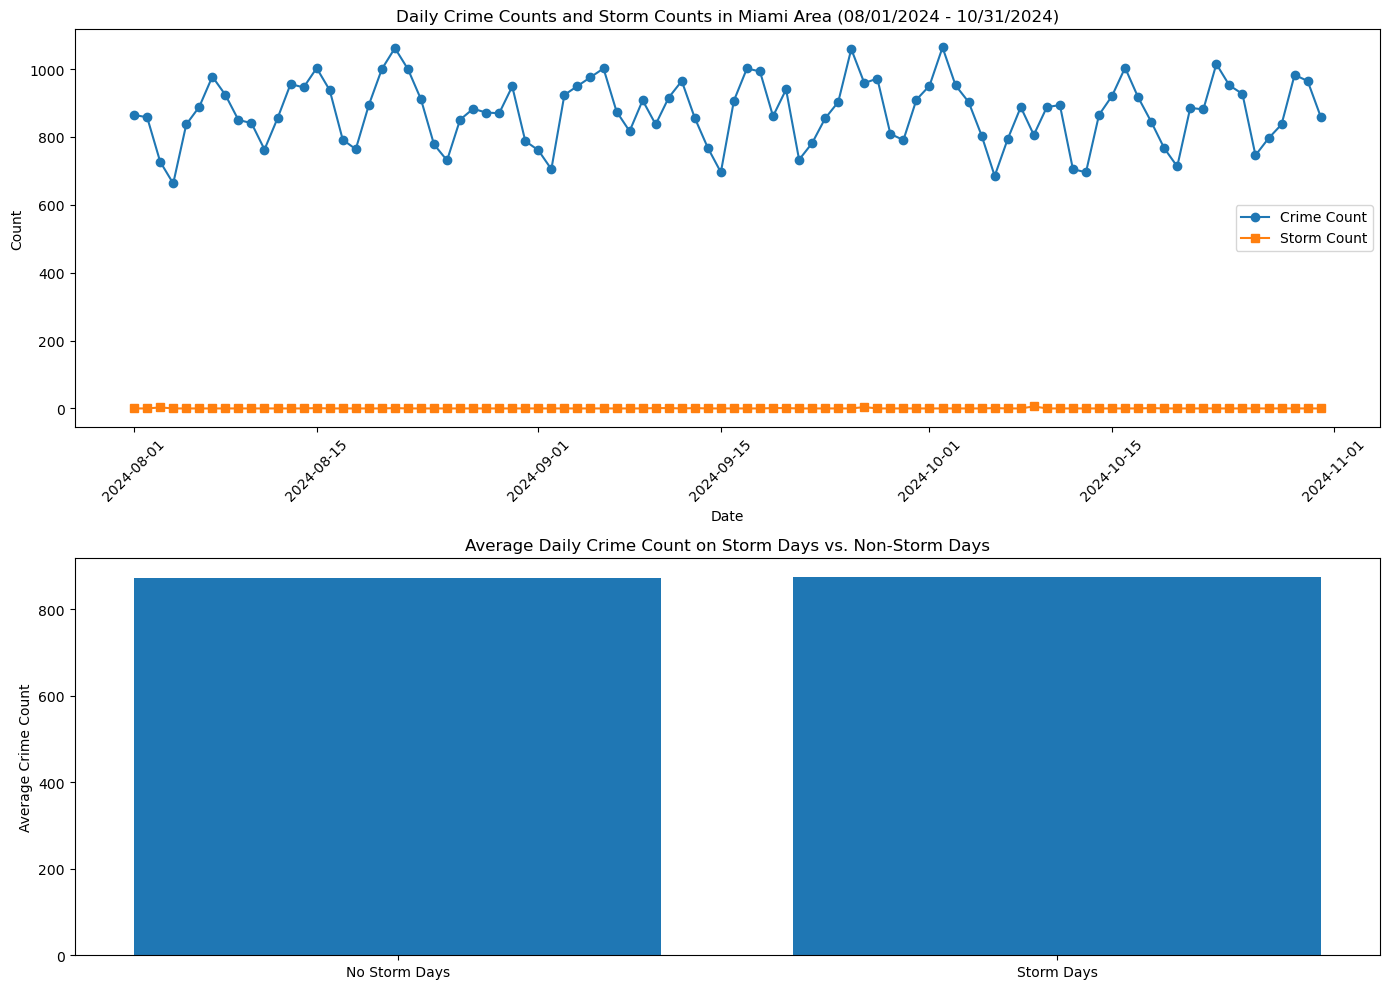

In [21]:
# Create a storm-day flag so crime can be compared on storm days versus non-storm days 
daily_summary['StormDay'] = np.where(daily_summary['StormCount'] > 0, 'Storm Day', 'No Storm Day') 

storm_day_summary = ( 
    daily_summary.groupby('StormDay')['CrimeCount'] 
    .agg(['count', 'mean', 'median', 'max']) 
    .round(2) 
) 

print("Crime summary by storm-day status:") 
print(storm_day_summary) 
print() 

# Correlation between daily storm counts and daily crime counts 
correlation = daily_summary['CrimeCount'].corr(daily_summary['StormCount']) 
print(f"Correlation between daily crime counts and daily storm counts: {correlation:.4f}") 
print() 

# Optional hypothesis test comparing crime counts on storm days and non-storm days 
try: 
    from scipy.stats import ttest_ind 

    crime_on_storm_days = daily_summary.loc[daily_summary['StormCount'] > 0, 'CrimeCount'] 
    crime_on_nonstorm_days = daily_summary.loc[daily_summary['StormCount'] == 0, 'CrimeCount'] 

    t_stat, p_value = ttest_ind( 
        crime_on_storm_days, 
        crime_on_nonstorm_days, 
        equal_var=False, 
        nan_policy='omit' 
    ) 

    print(f"T-test statistic: {t_stat:.4f}") 
    print(f"P-value: {p_value:.4f}") 
    print() 
except Exception as exc: 
    print("T-test could not be completed:", exc) 
    print() 

 

# Identify possible timeframes of interest for the Miami Police Department 
top_storm_dates = ( 
    daily_summary[daily_summary['StormCount'] > 0] 
    .sort_values(['CrimeCount', 'StormCount'], ascending=False) 
    .head(10) 
) 

print("Top dates with storm activity and the highest crime counts:") 
print(top_storm_dates[['Date', 'CrimeCount', 'StormCount']]) 
print() 

# Create visualizations for the report 
fig, axes = plt.subplots(2, 1, figsize=(14, 10)) 

# Line chart: daily crime counts and storm counts over time 
axes[0].plot(daily_summary['Date'], daily_summary['CrimeCount'], marker='o', linewidth=1.5, label='Crime Count') 
axes[0].plot(daily_summary['Date'], daily_summary['StormCount'], marker='s', linewidth=1.5, label='Storm Count') 
axes[0].set_title('Daily Crime Counts and Storm Counts in Miami Area (08/01/2024 - 10/31/2024)') 
axes[0].set_xlabel('Date') 
axes[0].set_ylabel('Count') 
axes[0].legend() 
axes[0].tick_params(axis='x', rotation=45) 

# Bar chart: average crime counts on storm days versus non-storm days 
avg_crime_no_storm = daily_summary.loc[daily_summary['StormCount'] == 0, 'CrimeCount'].mean() 
avg_crime_storm = daily_summary.loc[daily_summary['StormCount'] > 0, 'CrimeCount'].mean() 

axes[1].bar(['No Storm Days', 'Storm Days'], [avg_crime_no_storm, avg_crime_storm]) 
axes[1].set_title('Average Daily Crime Count on Storm Days vs. Non-Storm Days') 
axes[1].set_ylabel('Average Crime Count') 

plt.tight_layout() 
plt.show()

## Step 6: Save cleaned dataset and visualizations

You will save the cleaned dataset from your analysis to a .`csv` in the format  `DAT 375 Project One_Visualization_<your name>.csv` and visuals created to be saved as a `.png` picture file following the name convention replacing with your name:  `DAT 375 Project One_Visualization_<your name>.png`


In [22]:
csv_filename = 'DAT 375 Project One_Visualization_ShaunSanders.csv'
png_filename = 'DAT 375 Project One_Visualization_ShaunSanders.png' 

# Save the cleaned, merged daily dataset 
daily_summary.to_csv(csv_filename, index=False) 

# Save the visualizations created in Step 5 
fig.savefig(png_filename, dpi=300, bbox_inches='tight') 

print("Files saved successfully:") 
print(csv_filename) 
print(png_filename) 

Files saved successfully:
DAT 375 Project One_Visualization_ShaunSanders.csv
DAT 375 Project One_Visualization_ShaunSanders.png


## End of Lab

Please confirm that you have completed each of the asks and include necessary information for your Project. 



It is a good habit to confirm that all cells run when done with your analysis in a Jupyter Notebook. You also may find that the code has an error that was not realized due changes in your work throughout. To do this, please go to the top menu bar: 

**Kernel** --> **Restart Kernel and Run All Cells**

Did you make it back here with all cells running without error?

Please also complete all required screenshots and any files you needed to create.

Please confirm that you have saved all of your work for this lab within the ```MyWork``` folder.
